In [4]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# laoding cleaned data
traffic_df = pd.read_csv("../data/processed/traffic_cleaned.csv")
air_df = pd.read_csv("../data/processed/air_quality_cleaned.csv")

In [5]:
# Converting datetime columns
traffic_df['timestamp'] = pd.to_datetime(traffic_df['timestamp'])
air_df['last_update'] = pd.to_datetime(air_df['last_update'])

In [6]:
# creating traffic load metric
traffic_df['traffic_load'] = (
    traffic_df['car_count'] + 
    traffic_df['bike_count'] + 
    traffic_df['truck_count']
)

In [8]:
traffic_df[['car_count','bike_count','truck_count','traffic_load']].head()

,car_count,bike_count,truck_count,traffic_load
0,32,46,9,87
1,18,17,5,40
2,7,27,5,39
3,34,49,13,96
4,5,18,5,28


## Traffic Load by Area Type

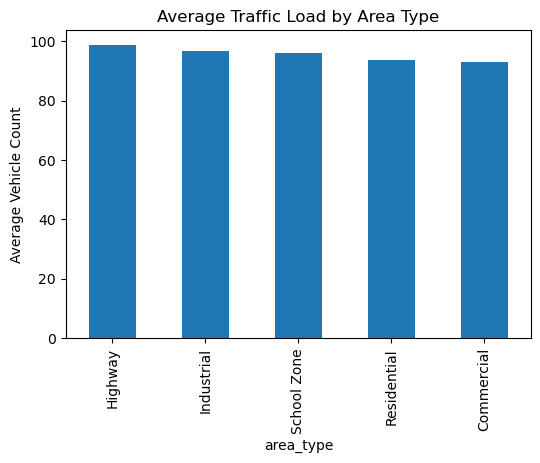

In [9]:
area_traffic = traffic_df.groupby('area_type')['traffic_load'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
area_traffic.plot(kind='bar')
plt.title("Average Traffic Load by Area Type")
plt.ylabel("Average Vehicle Count")
plt.show()

## Traffic Load by Hour (Peak Periods)

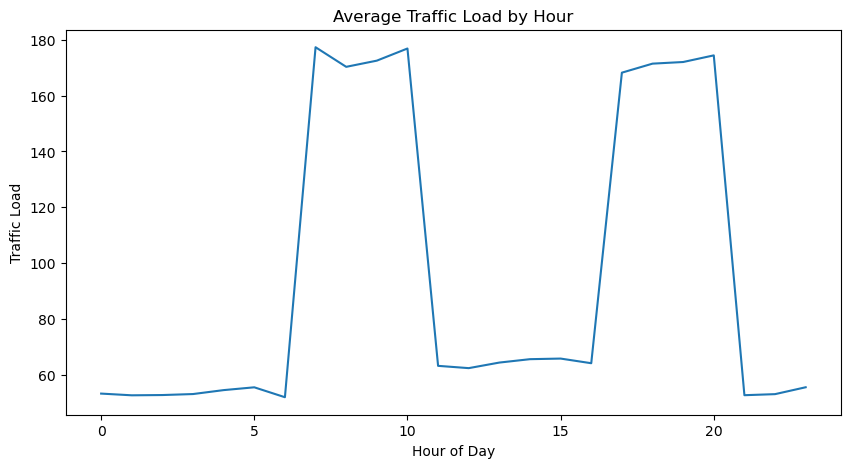

In [10]:
hourly_traffic = traffic_df.groupby('hour')['traffic_load'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_traffic.index, hourly_traffic.values)
plt.title("Average Traffic Load by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Traffic Load")
plt.show()

## Pollution by Pollutant Type

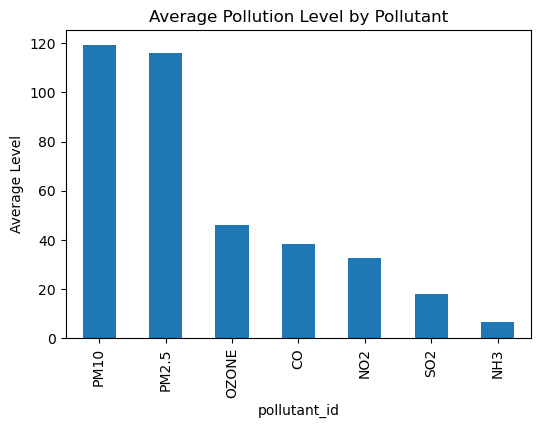

In [12]:
pollutant_levels = air_df.groupby('pollutant_id')['pollutant_avg'].mean().sort_values(ascending=False)

plt.figure(figsize=(6,4))
pollutant_levels.plot(kind='bar')
plt.title("Average Pollution Level by Pollutant")
plt.ylabel("Average Level")
plt.show()

## Most Polluted Cities

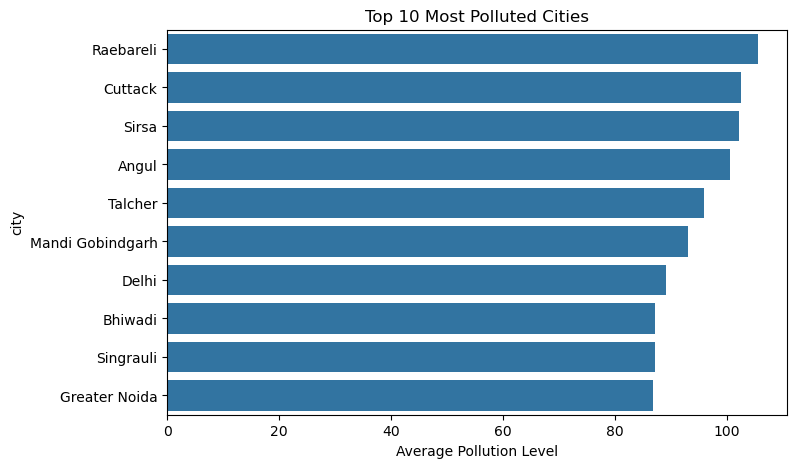

In [13]:
city_pollution = air_df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=city_pollution.values, y=city_pollution.index)
plt.title("Top 10 Most Polluted Cities")
plt.xlabel("Average Pollution Level")
plt.show()

## Pollution Distribution

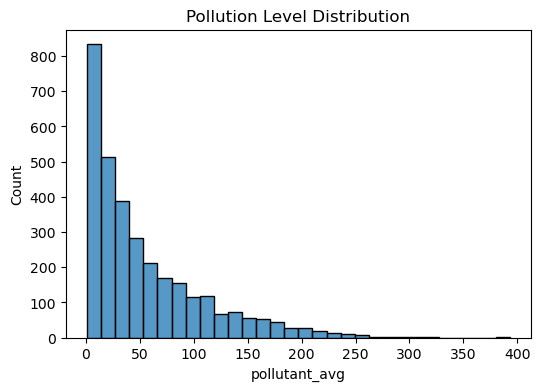

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(air_df['pollutant_avg'], bins=30)
plt.title("Pollution Level Distribution")
plt.show()

## Traffic vs Pollution Interpretation (Derived Comparison)

In [15]:
traffic_summary = traffic_df[['car_count','bike_count','truck_count','traffic_load']].mean()
traffic_summary

car_count       35.633000
bike_count      49.676600
truck_count     10.370133
traffic_load    95.679733
dtype: float64

In [16]:
pollution_summary = air_df.groupby('pollutant_id')['pollutant_avg'].mean()
pollution_summary

pollutant_id
CO        38.505241
NH3        6.766990
NO2       32.474249
OZONE     46.080851
PM10     119.378261
PM2.5    116.159483
SO2       18.121076
Name: pollutant_avg, dtype: float64

## Traffic Insights
- Commercial areas show the highest average traffic load.
- Peak congestion occurs during morning and evening hours.
- Cars dominate the traffic composition compared to bikes and trucks.

## Pollution Insights
- Certain pollutants (e.g., PM2.5 / PM10) show higher average levels.
- Some cities experience significantly higher pollution levels.

## Smart City Interpretation
- High traffic density areas are likely contributors to higher pollution levels.
- Urban planning should focus on traffic regulation in high-congestion zones.

## Preparing data for PowerBI

In [21]:
# creating date column
traffic_df['date'] = traffic_df['timestamp'].dt.date

In [25]:
conditions = [
    air_df['pollutant_avg'] <= 50,
    (air_df['pollutant_avg'] > 50) & (air_df['pollutant_avg'] <= 100),
    air_df['pollutant_avg'] > 100
]

levels = ['Low', 'Moderate', 'High']

air_df['pollution_level'] = np.select(conditions, levels, default='Unknown')

In [30]:
#creating city pollution summary
city_pollution = (
    air_df
    .groupby('city')['pollutant_avg']
    .mean()
    .reset_index()
)

city_pollution.rename(columns={'pollutant_avg':'avg_pollution'}, inplace=True)

In [31]:
# creating pollutant summary
pollutant_summary = (
    air_df
    .groupby('pollutant_id')['pollutant_avg']
    .mean()
    .reset_index()
)

pollutant_summary.rename(columns={'pollutant_avg':'avg_pollution'}, inplace=True)

In [32]:
#creatiung area traffic summary
area_traffic = (
    traffic_df
    .groupby('area_type')['traffic_load']
    .mean()
    .reset_index()
)

area_traffic.rename(columns={'traffic_load':'avg_traffic_load'}, inplace=True)

In [33]:
# creating hourly traffic summary
hourly_traffic = (
    traffic_df
    .groupby('hour')['traffic_load']
    .mean()
    .reset_index()
)

hourly_traffic.rename(columns={'traffic_load':'avg_traffic_load'}, inplace=True)

In [37]:
# exporting data for powerBI
traffic_df.to_csv("../data/processed/pbi_traffic_data.csv", index=False)
air_df.to_csv("../data/processed/pbi_air_quality_data.csv", index=False)
city_pollution.to_csv("../data/processed/pbi_city_pollution.csv", index=False)
pollutant_summary.to_csv("../data/processed/pbi_pollutant_summary.csv", index=False)
area_traffic.to_csv("../data/processed/pbi_area_traffic.csv", index=False)
hourly_traffic.to_csv("../data/processed/pbi_hourly_traffic.csv", index=False)

## Insights
- Traffic pressure is concentrated, not uniform: one-fifth of observations are high-density while most are low to medium, indicating targeted interventions are more effective than city-wide blanket controls.
- Congestion follows repeatable peak windows, especially morning and evening periods, making time-based traffic operations a practical and high-impact strategy.
- Highways and industrial corridors carry the highest average traffic load, identifying them as priority zones for mobility upgrades.
- Signal waiting time increases sharply in high-density conditions, showing that intersection performance is a critical bottleneck in urban flow efficiency.
- Urban traffic composition is dominated by bikes and cars, while trucks are fewer but still operationally important in specific freight corridors.
- PM10 and PM2.5 are the dominant pollutant burdens, suggesting particulate-focused mitigation should be central to environmental planning.
- Pollution intensity varies significantly across cities and states, confirming that geographically differentiated policy is necessary.
- Monitoring coverage is broad (many cities, states, and stations), which supports scalable benchmarking and city-level accountability.
- Traffic stress and pollution burden show strong co-location patterns at planning scale, supporting integrated transport-environment governance.
- Remaining null pollutant records indicate data quality gaps that can influence pollution categorization, so governance decisions should include data-confidence context.

## Recommendations
- Implement peak-hour traffic management plans (07:00-10:00 and 19:00-20:00) with adaptive signaling and lane-priority policies.
- Prioritize high-load corridors (highway and industrial zones) for junction redesign, queue management, and incident-response systems.
- Deploy intelligent signal control at high-delay intersections to reduce waiting time and stop-and-go emissions.
- Establish PM10/PM2.5 reduction programs combining road-dust suppression, construction compliance, and stricter vehicle-emission checks.
- Create city-specific clean-air action tiers using pollution severity bands instead of one uniform state-level strategy.
- Expand multimodal travel incentives (public transport, non-motorized mobility, shared commuting) to reduce private-vehicle pressure during peak windows.
- Introduce freight-time optimization for trucks in congested urban segments, including off-peak delivery windows where feasible.
- Build an integrated traffic-air dashboard for municipal teams, combining congestion, waiting time, and pollutant trends for faster decision cycles.
- Strengthen data governance by fixing missing pollutant values, validating station feeds, and enforcing periodic data-quality audits.
- Adopt phased implementation with KPI tracking (average delay, PM levels, congestion share, compliance rates) to measure policy impact and adjust rapidly.